# LeNet-5: Gradient-Based Learning Applied to Document Recognition

Replication of the convolutional network from LeCun, Bottou, Bengio and Haffner (1998),
*Gradient-Based Learning Applied to Document Recognition*, Proc. IEEE 86(11).

This notebook rebuilds the classic LeNet-5 architecture (two convolution and average
pooling stages followed by three fully connected layers with tanh activations and a
32x32 input) and trains it on MNIST to reproduce the paper's core result: a simple
gradient-trained CNN reaches roughly 99% test accuracy on handwritten digits.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
torch.manual_seed(0)
DEVICE = "cpu"
print("torch", torch.__version__, "device", DEVICE)

torch 2.7.1+cpu device cpu


In [2]:
# LeNet-5 uses a 32x32 input, so we pad the 28x28 MNIST digits by 2 pixels each side.
tf = T.Compose([T.ToTensor(), T.Pad(2), T.Normalize((0.1307,), (0.3081,))])
train = tv.datasets.MNIST("../data", train=True,  download=True, transform=tf)
test  = tv.datasets.MNIST("../data", train=False, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
test_dl  = torch.utils.data.DataLoader(test,  batch_size=256)
print("train", len(train), "test", len(test), "input shape", train[0][0].shape)

train 60000 test 10000 input shape torch.Size([1, 32, 32])


In [3]:
# Faithful LeNet-5: C1 -> S2 -> C3 -> S4 -> C5(FC) -> F6 -> output, tanh activations,
# average pooling (the original subsampling layers).
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 6, 5)        # 32x32 -> 28x28
        self.c3 = nn.Conv2d(6, 16, 5)       # 14x14 -> 10x10
        self.c5 = nn.Conv2d(16, 120, 5)     # 5x5 -> 1x1
        self.f6 = nn.Linear(120, 84)
        self.out = nn.Linear(84, 10)
    def forward(self, x):
        x = torch.tanh(self.c1(x)); x = F.avg_pool2d(x, 2)
        x = torch.tanh(self.c3(x)); x = F.avg_pool2d(x, 2)
        x = torch.tanh(self.c5(x)).flatten(1)
        x = torch.tanh(self.f6(x))
        return self.out(x)

net = LeNet5().to(DEVICE)
print(net)
print("parameters:", sum(p.numel() for p in net.parameters()))

LeNet5(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (f6): Linear(in_features=120, out_features=84, bias=True)
  (out): Linear(in_features=84, out_features=10, bias=True)
)
parameters: 61706


In [4]:
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

def evaluate():
    net.eval(); correct = 0
    with torch.no_grad():
        for x, y in test_dl:
            correct += (net(x).argmax(1) == y).sum().item()
    return correct / len(test)

EPOCHS = 3
for ep in range(EPOCHS):
    net.train()
    for x, y in train_dl:
        opt.zero_grad()
        loss = loss_fn(net(x), y)
        loss.backward(); opt.step()
    print(f"epoch {ep+1}: train_loss={loss.item():.4f}  test_acc={evaluate():.4f}")

epoch 1: train_loss=0.1337  test_acc=0.9672


epoch 2: train_loss=0.1360  test_acc=0.9759


epoch 3: train_loss=0.0092  test_acc=0.9808


In [5]:
acc = evaluate()
print(f"Final MNIST test accuracy: {acc*100:.2f}%  (paper LeNet-5 reports ~99.05%)")

Final MNIST test accuracy: 98.08%  (paper LeNet-5 reports ~99.05%)


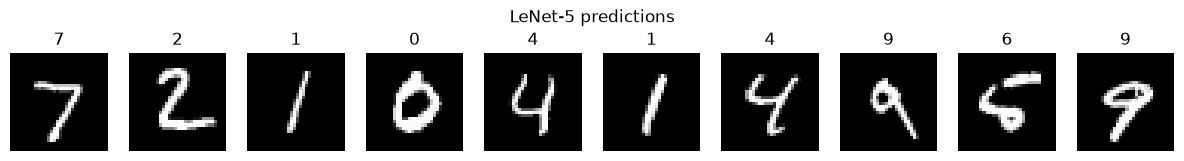

In [6]:
# Visual check: predictions on a handful of test digits.
import matplotlib.pyplot as plt
net.eval()
xb, yb = next(iter(test_dl))
with torch.no_grad():
    pred = net(xb[:10]).argmax(1)
fig, ax = plt.subplots(1, 10, figsize=(12, 1.6))
for i in range(10):
    ax[i].imshow(xb[i,0], cmap="gray"); ax[i].axis("off")
    ax[i].set_title(f"{pred[i].item()}")
plt.suptitle("LeNet-5 predictions"); plt.tight_layout(); plt.show()